# Leading Feature Engineering and Validation

Builds pre-outcome behavioral decay features and validates their direction, coverage, discrimination, and stability.

**Execution contract:** run from top to bottom. The notebook writes reproducible artifacts under `data/processed/` and `reports/`; raw data and large generated artifacts remain outside Git.


## 1. Imports and configuration

Pin project-relative paths and load the exact analytical dependencies used by the workflow.


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src.features_leading import build_leading_features  # noqa: E402


PROCESSED = ROOT / "data" / "processed" / "instacart"
LABELS = PROCESSED / "labels" / "instacart_phase2_decay_labels.csv"
FEATURE_DIR = PROCESSED / "features"
REPORT = ROOT / "reports" / "features" / "instacart"
PLOTS = REPORT / "plots"


FEATURE_INPUT_COLS = [
    "order_id",
    "user_id",
    "eval_set",
    "order_number",
    "order_dow",
    "order_hour_of_day",
    "days_since_prior_order",
    "item_count",
    "distinct_aisle_count",
    "distinct_department_count",
    "reorder_ratio",
    "prior_avg_gap_days",
    "prior_avg_item_count",
    "prior_avg_reorder_ratio",
    "prior_avg_distinct_department_count",
]

VALIDATION_FEATURES = {
    "current_gap_ratio_to_historical_median": "high",
    "latest_gap_ratio_to_prior_avg": "high",
    "latest_gap_ratio_to_previous_gap": "high",
    "gap_slope_last3": "high",
    "purchase_frequency_slope_last3": "low",
    "item_count_recent3_ratio_to_prior": "low",
    "reorder_ratio_recent3_delta_from_prior": "low",
    "reorder_ratio_slope_last3": "low",
    "distinct_department_count_recent3_ratio_to_prior": "low",
    "distinct_aisle_count_recent3_ratio_to_prior": "low",
    "hour_distance_from_prior_pattern": "high",
    "dow_distance_from_prior_pattern": "high",
    "history_reliability_score": "high",
}


## 2. Reusable analytical helpers

Define validation, transformation, scoring, and reporting helpers without mutating project artifacts.


In [2]:
def ensure_dirs() -> None:
    FEATURE_DIR.mkdir(parents=True, exist_ok=True)
    REPORT.mkdir(parents=True, exist_ok=True)
    PLOTS.mkdir(parents=True, exist_ok=True)


def pct(value: float) -> str:
    return f"{value:.2%}"


def auc_score(values: pd.Series, labels: pd.Series, *, high_is_risk: bool) -> float:
    tmp = pd.DataFrame({"value": values, "label": labels}).dropna()
    if tmp["label"].nunique() < 2:
        return float("nan")
    ranks = tmp["value"].rank(method="average")
    pos = tmp["label"].astype(bool)
    n_pos = int(pos.sum())
    n_neg = int((~pos).sum())
    auc_high = (float(ranks[pos].sum()) - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)
    return auc_high if high_is_risk else 1 - auc_high


def summarize_feature(df: pd.DataFrame, feature: str, direction: str) -> dict[str, float | int | str]:
    tmp = df[[feature, "early_decay_label"]].dropna()
    if tmp.empty:
        return {
            "feature": feature,
            "risk_direction": direction,
            "rows": 0,
        }

    high_is_risk = direction == "high"
    threshold = tmp[feature].quantile(0.90 if high_is_risk else 0.10)
    segment = tmp[feature].ge(threshold) if high_is_risk else tmp[feature].le(threshold)
    baseline = float(tmp["early_decay_label"].mean())
    segment_rate = float(tmp.loc[segment, "early_decay_label"].mean())
    retained = tmp.loc[~tmp["early_decay_label"], feature]
    churned = tmp.loc[tmp["early_decay_label"], feature]
    return {
        "feature": feature,
        "risk_direction": direction,
        "rows": int(tmp.shape[0]),
        "retained_median": float(retained.median()),
        "decay_median": float(churned.median()),
        "retained_mean": float(retained.mean()),
        "decay_mean": float(churned.mean()),
        "risk_decile_threshold": float(threshold),
        "baseline_decay_rate": baseline,
        "risk_decile_decay_rate": segment_rate,
        "risk_decile_lift": float(segment_rate / baseline) if baseline else float("nan"),
        "univariate_auc_directional": auc_score(tmp[feature], tmp["early_decay_label"], high_is_risk=high_is_risk),
    }


def save_boxplot(df: pd.DataFrame, feature: str, direction: str) -> None:
    tmp = df[[feature, "early_decay_label"]].dropna()
    if tmp.empty:
        return
    lower = tmp[feature].quantile(0.01)
    upper = tmp[feature].quantile(0.99)
    retained = tmp.loc[~tmp["early_decay_label"], feature].clip(lower=lower, upper=upper)
    decay = tmp.loc[tmp["early_decay_label"], feature].clip(lower=lower, upper=upper)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot([retained, decay], tick_labels=["Retained", "Early decay"], showfliers=False)
    ax.set_title(feature.replace("_", " "))
    ax.set_ylabel("Feature value, clipped p1-p99")
    ax.set_xlabel(f"Risk direction: {direction}")
    fig.tight_layout()
    fig.savefig(PLOTS / f"{feature}_by_label.png", dpi=140)
    plt.close(fig)


def add_prior_average(df: pd.DataFrame, col: str, out_col: str) -> pd.DataFrame:
    valid = df[col].notna()
    cumulative = df[col].fillna(0).groupby(df["user_id"], sort=False).cumsum()
    valid_count = valid.astype("int32").groupby(df["user_id"], sort=False).cumsum()
    prior_sum = cumulative - df[col].fillna(0)
    prior_count = valid_count - valid.astype("int32")
    df[out_col] = (prior_sum / prior_count.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    return df


## 3. Pipeline definition

Define the end-to-end workflow. Execution is deliberately isolated in the next cell so the expensive step is explicit.


In [3]:
def main() -> None:
    ensure_dirs()
    behavior = pd.read_csv(PROCESSED / "user_order_behavior_base.csv", usecols=FEATURE_INPUT_COLS)
    labels = pd.read_csv(
        LABELS,
        usecols=[
            "order_id",
            "historical_median_gap_days",
            "label_eligible",
            "label_status",
            "early_decay_label",
            "split",
        ],
    )
    behavior = behavior.sort_values(["user_id", "order_number", "order_id"]).copy()
    behavior = add_prior_average(behavior, "distinct_aisle_count", "prior_avg_distinct_aisle_count")
    behavior = behavior.merge(
        labels[["order_id", "historical_median_gap_days"]],
        on="order_id",
        how="left",
        validate="one_to_one",
    )

    features = build_leading_features(behavior)

    validation = features.merge(
        labels.drop(columns=["historical_median_gap_days"]),
        on="order_id",
        how="inner",
        validate="one_to_one",
    )
    validation = validation[validation["label_eligible"]].copy()
    validation["early_decay_label"] = validation["early_decay_label"].astype(bool)

    target_cols = ["user_id", "order_id", "split", "early_decay_label"]
    leakage_cols = {"label_eligible", "label_status", "early_decay_label", "split"}
    metadata_cols = {"eval_set", "order_number"}
    model_features = validation[[c for c in validation.columns if c not in leakage_cols | metadata_cols]].copy()
    targets = validation[target_cols].copy()

    model_features.to_pickle(FEATURE_DIR / "instacart_leading_features_model_input.pkl")
    targets.to_pickle(FEATURE_DIR / "instacart_leading_feature_targets.pkl")
    model_features.sample(min(len(model_features), 100_000), random_state=42).to_csv(
        FEATURE_DIR / "instacart_leading_features_model_input_sample.csv",
        index=False,
    )
    targets.sample(min(len(targets), 100_000), random_state=42).to_csv(
        FEATURE_DIR / "instacart_leading_feature_targets_sample.csv",
        index=False,
    )

    feature_summaries = [
        summarize_feature(validation, feature, direction)
        for feature, direction in VALIDATION_FEATURES.items()
    ]
    feature_summaries = sorted(
        feature_summaries,
        key=lambda row: row.get("univariate_auc_directional", float("-inf")),
        reverse=True,
    )

    plot_validation = pd.concat(
        [
            validation.loc[~validation["early_decay_label"]].sample(
                min((~validation["early_decay_label"]).sum(), 125_000),
                random_state=42,
            ),
            validation.loc[validation["early_decay_label"]].sample(
                min(validation["early_decay_label"].sum(), 125_000),
                random_state=42,
            ),
        ],
        ignore_index=True,
    )
    for feature, direction in VALIDATION_FEATURES.items():
        save_boxplot(plot_validation, feature, direction)

    feature_cols = [c for c in features.columns if c not in {"user_id", "order_id", "eval_set", "order_number"}]
    null_rates = (
        features[feature_cols]
        .isna()
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .to_dict()
    )

    report = {
        "inputs": {
            "behavior_rows": int(behavior.shape[0]),
            "label_rows": int(labels.shape[0]),
            "label_eligible_rows_used_for_validation": int(validation.shape[0]),
        },
        "outputs": {
            "features_pickle": (FEATURE_DIR / "instacart_leading_features_model_input.pkl").relative_to(ROOT).as_posix(),
            "targets_pickle": (FEATURE_DIR / "instacart_leading_feature_targets.pkl").relative_to(ROOT).as_posix(),
            "features_sample_csv": (FEATURE_DIR / "instacart_leading_features_model_input_sample.csv").relative_to(ROOT).as_posix(),
            "targets_sample_csv": (FEATURE_DIR / "instacart_leading_feature_targets_sample.csv").relative_to(ROOT).as_posix(),
            "report_json": (REPORT / "instacart_leading_features_report.json").relative_to(ROOT).as_posix(),
            "report_md": (REPORT / "instacart_leading_features_report.md").relative_to(ROOT).as_posix(),
            "plots_dir": PLOTS.relative_to(ROOT).as_posix(),
        },
        "feature_count": len(feature_cols),
        "top_null_rates": {key: float(value) for key, value in null_rates.items()},
        "feature_summaries": feature_summaries,
        "leakage_note": "Feature generation uses current and historical order behavior only. The historical median gap is reused from Phase 2 snapshot metadata, but target labels and next_gap columns are used only after feature creation for validation plots/statistics. Model-input feature files are saved without early_decay_label, label_eligible, label_status, or split; split lives in the target table.",
    }

    with (REPORT / "instacart_leading_features_report.json").open("w", encoding="utf-8") as f:
        json.dump(report, f, indent=2, default=str)

    lines = [
        "# Instacart Leading Feature Validation",
        "",
        "## Scope",
        "",
        "Built leakage-safe behavioral decay features from current and historical user-order behavior. The future label is used only for validation.",
        "",
        "## Outputs",
        "",
        f"- Model-input feature table: `{report['outputs']['features_pickle']}`",
        f"- Target table: `{report['outputs']['targets_pickle']}`",
        f"- Feature CSV inspection sample: `{report['outputs']['features_sample_csv']}`",
        f"- Target CSV inspection sample: `{report['outputs']['targets_sample_csv']}`",
        f"- Plots: `{report['outputs']['plots_dir']}`",
        "",
        "## Row Counts",
        "",
        f"- Behavior rows processed: {report['inputs']['behavior_rows']:,}",
        f"- Label rows available: {report['inputs']['label_rows']:,}",
        f"- Label-eligible rows used for validation: {report['inputs']['label_eligible_rows_used_for_validation']:,}",
        f"- Feature columns created: {report['feature_count']:,}",
        "",
        "## Feature Separation Summary",
        "",
        "| Feature | Risk Direction | Retained Median | Decay Median | Risk-Decile Decay Rate | Lift | AUC |",
        "|---|---:|---:|---:|---:|---:|---:|",
    ]
    for row in feature_summaries:
        if row.get("rows", 0) == 0:
            continue
        risk_decile_rate = pct(float(row["risk_decile_decay_rate"]))
        lines.append(
            f"| {row['feature']} | {row['risk_direction']} | "
            f"{float(row['retained_median']):.3f} | {float(row['decay_median']):.3f} | "
            f"{risk_decile_rate} | {float(row['risk_decile_lift']):.2f} | "
            f"{float(row['univariate_auc_directional']):.3f} |"
        )

    lines.extend(
        [
            "",
            "## Practical Read",
            "",
            "- Features with AUC close to 0.50 have weak standalone separation and should not be oversold.",
            "- Gap/cadence features are expected to be strongest because the Phase 2 label is also purchase-rhythm based.",
            "- Basket, reorder, category, and time-consistency features are still useful if they add incremental signal in a multivariate model.",
            "",
            "## Leakage Control",
            "",
            report["leakage_note"],
        ]
    )
    (REPORT / "instacart_leading_features_report.md").write_text("\n".join(lines) + "\n", encoding="utf-8")

    print(json.dumps({"features_rows": int(features.shape[0]), "validation_rows": int(validation.shape[0])}, indent=2))


## 4. Execute the workflow

Run the complete stage and retain its console output in the committed notebook.


In [4]:
main()


{
  "features_rows": 3346083,
  "validation_rows": 2489335
}


## 5. Results and generated evidence

Render the generated report directly in the notebook so GitHub visitors can inspect results without running the project.


# Instacart Leading Feature Validation

## Scope

Built leakage-safe behavioral decay features from current and historical user-order behavior. The future label is used only for validation.

## Outputs

- Model-input feature table: `data/processed/instacart/features/instacart_leading_features_model_input.pkl`
- Target table: `data/processed/instacart/features/instacart_leading_feature_targets.pkl`
- Feature CSV inspection sample: `data/processed/instacart/features/instacart_leading_features_model_input_sample.csv`
- Target CSV inspection sample: `data/processed/instacart/features/instacart_leading_feature_targets_sample.csv`
- Plots: `reports/features/instacart/plots`

## Row Counts

- Behavior rows processed: 3,346,083
- Label rows available: 3,346,083
- Label-eligible rows used for validation: 2,489,335
- Feature columns created: 38

## Feature Separation Summary

| Feature | Risk Direction | Retained Median | Decay Median | Risk-Decile Decay Rate | Lift | AUC |
|---|---:|---:|---:|---:|---:|---:|
| current_gap_ratio_to_historical_median | high | 1.000 | 1.000 | 34.04% | 1.90 | 0.575 |
| latest_gap_ratio_to_prior_avg | high | 0.856 | 0.887 | 31.78% | 1.78 | 0.533 |
| gap_slope_last3 | high | 0.000 | 0.000 | 24.63% | 1.38 | 0.524 |
| purchase_frequency_slope_last3 | low | 0.000 | 0.000 | 21.34% | 1.21 | 0.519 |
| item_count_recent3_ratio_to_prior | low | 0.989 | 0.979 | 19.64% | 1.10 | 0.511 |
| distinct_aisle_count_recent3_ratio_to_prior | low | 0.997 | 0.988 | 19.60% | 1.10 | 0.509 |
| distinct_department_count_recent3_ratio_to_prior | low | 1.000 | 1.000 | 19.49% | 1.09 | 0.508 |
| latest_gap_ratio_to_previous_gap | high | 1.000 | 1.000 | 23.11% | 1.30 | 0.508 |
| dow_distance_from_prior_pattern | high | 1.319 | 1.343 | 17.97% | 1.01 | 0.505 |
| hour_distance_from_prior_pattern | high | 2.563 | 2.564 | 18.14% | 1.01 | 0.501 |
| reorder_ratio_slope_last3 | low | 0.000 | 0.000 | 19.06% | 1.07 | 0.495 |
| reorder_ratio_recent3_delta_from_prior | low | 0.152 | 0.157 | 17.59% | 0.98 | 0.489 |
| history_reliability_score | high | 1.000 | 1.000 | 17.28% | 0.97 | 0.485 |

## Practical Read

- Features with AUC close to 0.50 have weak standalone separation and should not be oversold.
- Gap/cadence features are expected to be strongest because the Phase 2 label is also purchase-rhythm based.
- Basket, reorder, category, and time-consistency features are still useful if they add incremental signal in a multivariate model.

## Leakage Control

Feature generation uses current and historical order behavior only. The historical median gap is reused from Phase 2 snapshot metadata, but target labels and next_gap columns are used only after feature creation for validation plots/statistics. Model-input feature files are saved without early_decay_label, label_eligible, label_status, or split; split lives in the target table.


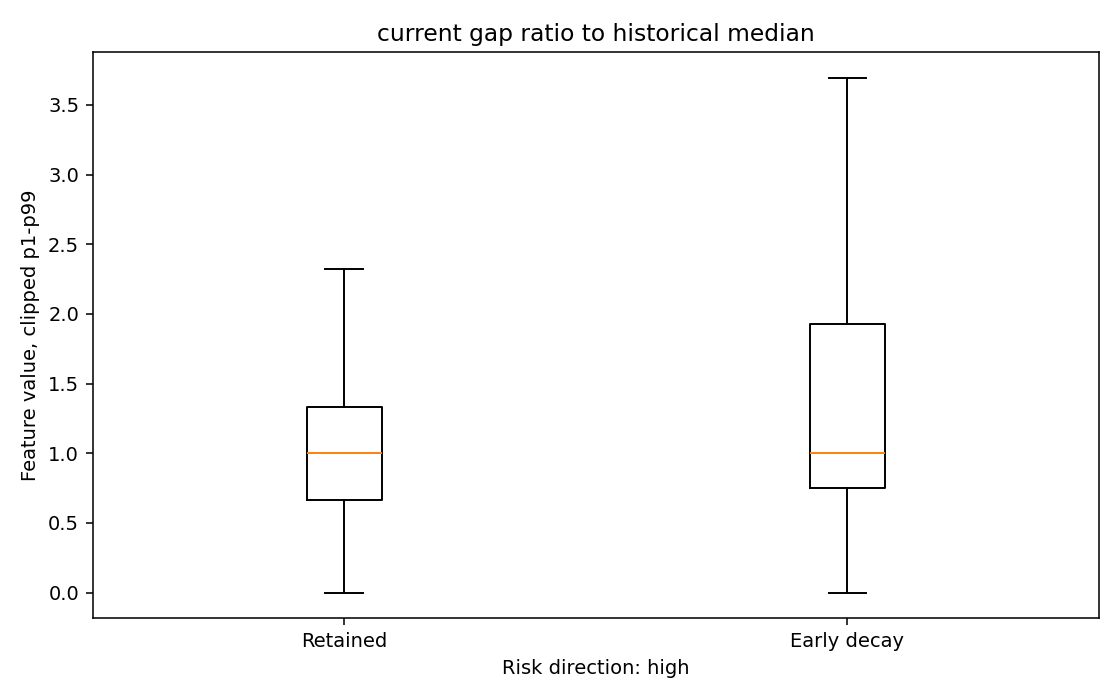

In [5]:
from IPython.display import Image, Markdown, display
report_path = ROOT.joinpath(*["reports","features","instacart","instacart_leading_features_report.md"])
display(Markdown(report_path.read_text(encoding="utf-8")))
evidence_plot = ROOT.joinpath(*["reports","features","instacart","plots","current_gap_ratio_to_historical_median_by_label.png"])
display(Image(filename=str(evidence_plot)))
